## Reproducing Mazeh+15 samples

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from plotutils import *

### KIC

In [2]:
dkic = pd.read_csv("data/kepler_stellar_17.csv", comment='#', delimiter="|")

### M15 KOI sample

In [3]:
dm15 = pd.read_csv("data/mazeh+15_table1.tsv", delimiter="|", comment="#")
dm15 = pd.merge(dm15, dkic[['kepid', 'kepmag']], left_on='KIC', right_on='kepid')
print(f"# M15 KOI all: {len(dm15)}.")

# M15 KOI all: 3355.


In [4]:
flag_list = ['D', 'N', 'F', 'G', 'T']
flag_remove = ['F', 'G', 'T']
# D: DC2013
# N: NEA
# F: EB (even-odd difference)
# G: giant (Teff-logg)
# T: Teff out of range

In [5]:
dm15_acf = dm15[dm15[flag_remove].sum(axis=1) == 0].reset_index(drop=True)
print(f"# M15 KOI removing FGT: {len(dm15_acf)}.")

# M15 KOI removing FGT: 3091.


In [6]:
acf_flag_list = ['M1', 'M2', 'R']
contami_flag_list = ['C']
kic_removed = 8043882
# M1: inconsistent Prot in different Q
# M2: ACF peak not high enough
# R: visual inspection
# C: contamination

In [7]:
print(f"# Prot detections from AutoACF: {np.sum(dm15_acf[acf_flag_list].sum(axis=1) == 0)}")
print(f"# Prot detections from AutoACF after removing C: {np.sum(dm15_acf[acf_flag_list+contami_flag_list].sum(axis=1) == 0)}")

# Prot detections from AutoACF: 1012
# Prot detections from AutoACF after removing C: 994


In [8]:
idx_koi = (dm15_acf[acf_flag_list+contami_flag_list].sum(axis=1) == 0) & (dm15_acf.kepid != kic_removed)
dm15_koi = dm15_acf[idx_koi].reset_index(drop=True)
print(f"# final KOI sample in Mazeh+15: {len(dm15_koi)}.") # should be 993

# final KOI sample in Mazeh+15: 993.


In [9]:
dm15_koi['r'] = [float(R_) for R_ in dm15_koi['Rvar']]
dm15_koi['logr'] = np.log10(dm15_koi.r)

In [10]:
# KOIs for which Prot has been searched
idx_koi_acf = (dm15_acf['C']==0) & (dm15_acf.kepid != kic_removed)
dm15_koi_searched = dm15_acf[idx_koi_acf].reset_index(drop=True)
dm15_koi_searched['r'] = [float(R_) for R_ in dm15_koi_searched['Rvar']]
dm15_koi_searched['logr'] = np.log10(dm15_koi_searched.r)

/Users/k_masuda/.pyenv/versions/anaconda3-5.3.1/envs/jnkepler/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


### M14 KIC sample

In [11]:
keys_det = []
for key in dkic.keys():
    if 'cdpp' in key:
        keys_det.append(key)
    elif key in ['dataspan', 'dutycycle']:
        keys_det.append(key)
print(keys_det)

['dutycycle', 'dataspan', 'rrmscdpp01p5', 'rrmscdpp02p0', 'rrmscdpp02p5', 'rrmscdpp03p0', 'rrmscdpp03p5', 'rrmscdpp04p5', 'rrmscdpp05p0', 'rrmscdpp06p0', 'rrmscdpp07p5', 'rrmscdpp09p0', 'rrmscdpp10p5', 'rrmscdpp12p0', 'rrmscdpp12p5', 'rrmscdpp15p0', 'cdppslplong', 'cdppslpshrt']


In [12]:
dm14_kic = pd.read_csv("data/mcquillan+14_table1.tsv", delimiter="|", comment="#")
dm14_kic = pd.merge(dm14_kic, dkic[['kepid', 'kepmag']+keys_det], left_on='KIC', right_on='kepid')
print(f"# M14 KIC all: {len(dm14_kic)}.")

# M14 KIC all: 34030.


In [13]:
dm14_kic_searched = pd.read_csv("data/mcquillan+14_table2.tsv", delimiter="|", comment="#")
dm14_kic_searched = pd.merge(dm14_kic_searched, dkic[['kepid', 'kepmag']+keys_det], left_on='KIC', right_on='kepid')
dm14_kic_searched = pd.concat([dm14_kic, dm14_kic_searched]).reset_index(drop=True)
print(f"# M14 KIC searched: {len(dm14_kic_searched)}.")

# M14 KIC searched: 133028.


In [14]:
dm14_kic['r'] = dm14_kic['Rper']
dm14_kic['logr'] = np.log10(dm14_kic.r)

dm14_kic_searched['r'] = dm14_kic_searched['Rper']
dm14_kic_searched['logr'] = np.log10(dm14_kic_searched.r)

In [15]:
teff_cut = (3500. < dm14_kic.Teff) & (dm14_kic.Teff < 6500.)
dm14_kic = dm14_kic[teff_cut].reset_index(drop=True)
print(f"# final KIC sample in Mazeh+15: {len(dm14_kic)}.") # should be 33614

# final KIC sample in Mazeh+15: 33614.


### save

In [ ]:
dirname = 'data_m15'
dm15_koi.to_csv(dirname+"/m15_koi.csv", index=False)
dm14_kic.to_csv(dirname+"/m15_kic.csv", index=False)
dm15_koi_searched.to_csv(dirname+"/m15_koi_searched.csv", index=False)
dm14_kic_searched.to_csv(dirname+"/m15_kic_searched.csv", index=False)

### check plot

In [17]:
np.max(dm14_kic_searched.Teff), np.max(dm14_kic.Teff), np.max(dm15_koi.Teff), np.max(dm14_kic.Teff)

(6499, 6499, 6499, 6499)

In [18]:
np.min(dm14_kic_searched.Teff), np.min(dm14_kic.Teff), np.min(dm15_koi.Teff), np.min(dm14_kic.Teff)

(3197, 3501, 3504, 3501)

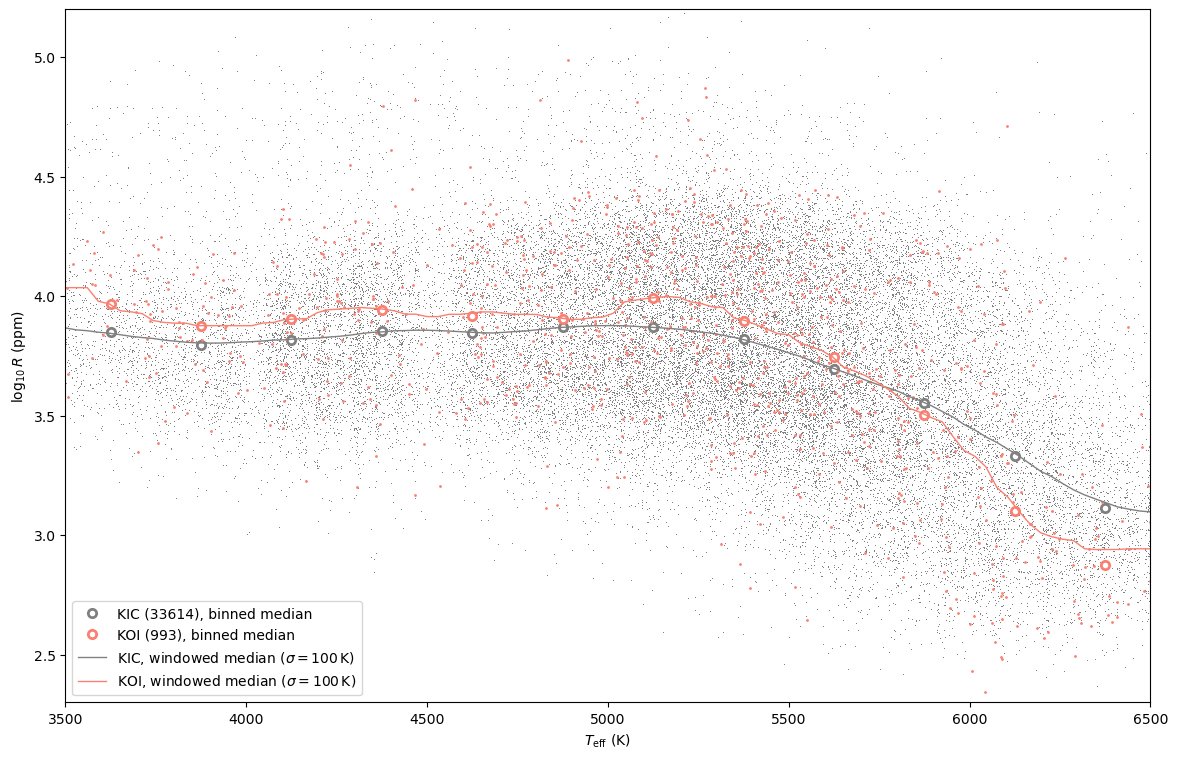

In [22]:
fig = plot(dm14_kic, dm15_koi, teff_sigma=100.)
plt.savefig('figs/m15_reproduced.png', dpi=200, bbox_inches="tight");